## 📦 Imports

Importing all required libraries for data manipulation, visualization.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit

## 📂 Load Dataset

Loading the training and test datasets.

- The dataset path is controlled by the `DATASET_PATH` environment variable  
- If not set, it defaults to a local folder named `dataset/`
- Files used:
  - `train.csv`
  - `test.csv`

Previewing dataset shape and sample rows.

In [2]:
DATASET_PATH = Path(os.getenv("DATASET_PATH", "dataset"))

df = pd.read_csv(DATASET_PATH / "train.csv")
test_df = pd.read_csv(DATASET_PATH / "test.csv")

print("Train shape:", df.shape)
print("Test shape:", test_df.shape)

df.head()

Train shape: (33126, 8)
Test shape: (10982, 5)


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


Basic dataset structure and missing values.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33126 entries, 0 to 33125
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     33126 non-null  str    
 1   patient_id                     33126 non-null  str    
 2   sex                            33061 non-null  str    
 3   age_approx                     33058 non-null  float64
 4   anatom_site_general_challenge  32599 non-null  str    
 5   diagnosis                      33126 non-null  str    
 6   benign_malignant               33126 non-null  str    
 7   target                         33126 non-null  int64  
dtypes: float64(1), int64(1), str(6)
memory usage: 2.0 MB


Summary statistics of numerical features.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_approx,33058.0,48.870016,14.380360,0.0,40.0,50.0,60.0,90.0
target,33126.0,0.017630,0.131603,0.0,0.0,0.0,0.0,1.0


Checking for duplicate rows.

In [5]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


Number of missing values per column.

In [6]:
df.isnull().sum().sort_values(ascending=False)

anatom_site_general_challenge    527
age_approx                        68
sex                               65
image_name                         0
patient_id                         0
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64

Percentage of missing values per column.

In [7]:
df.isna().mean().sort_values(ascending=False)*100

anatom_site_general_challenge    1.590895
age_approx                       0.205277
sex                              0.196220
image_name                       0.000000
patient_id                       0.000000
diagnosis                        0.000000
benign_malignant                 0.000000
target                           0.000000
dtype: float64

Class counts and percentage distribution of the target variable.

In [8]:
df['target'].value_counts()

target
0    32542
1      584
Name: count, dtype: int64

In [9]:
df['target'].value_counts(normalize=True) * 100

target
0    98.237034
1     1.762966
Name: proportion, dtype: float64

## 📊 Target Distribution Insight

The dataset is highly imbalanced.

- The majority of samples belong to the benign class (0)
- Malignant cases (1) represent only a very small portion of the data

This extreme class imbalance indicates that special techniques (e.g., class weighting or augmentation) may be needed during training.

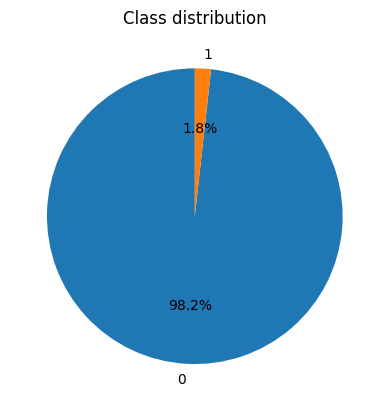

In [37]:
df['target'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Class distribution')
plt.ylabel('')
plt.show()

In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt

sizes = []

for img_name in os.listdir(train_path)[:100]:
    img = Image.open(os.path.join(train_path, img_name))
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=['width','height'])
sizes_df.plot(kind='scatter', x='width', y='height', title='Image dimensions')
plt.show()

In [11]:
print("Unique patients:", df["patient_id"].nunique())
df["patient_id"].value_counts().head(10)

Unique patients: 2056


patient_id
IP_7279968    115
IP_4479736    115
IP_4938382    115
IP_4382720    115
IP_0656529    114
IP_4488328    104
IP_9147454    102
IP_3057277    102
IP_1139701    102
IP_6245507    102
Name: count, dtype: int64

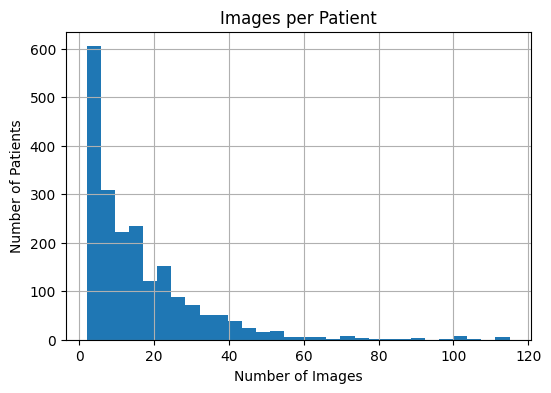

In [12]:
patient_counts = df["patient_id"].value_counts()

plt.figure(figsize=(6, 4))
patient_counts.hist(bins=30)
plt.title("Images per Patient")
plt.xlabel("Number of Images")
plt.ylabel("Number of Patients")
plt.show()

In [13]:
train_patients = set(df["patient_id"].dropna())
test_patients = set(test_df["patient_id"].dropna())

overlap = train_patients.intersection(test_patients)

print("Train unique patients:", len(train_patients))
print("Test unique patients:", len(test_patients))
print("Overlapping patients:", len(overlap))

Train unique patients: 2056
Test unique patients: 690
Overlapping patients: 0


In [14]:
df["age_approx"].describe()

count    33058.000000
mean        48.870016
std         14.380360
min          0.000000
25%         40.000000
50%         50.000000
75%         60.000000
max         90.000000
Name: age_approx, dtype: float64

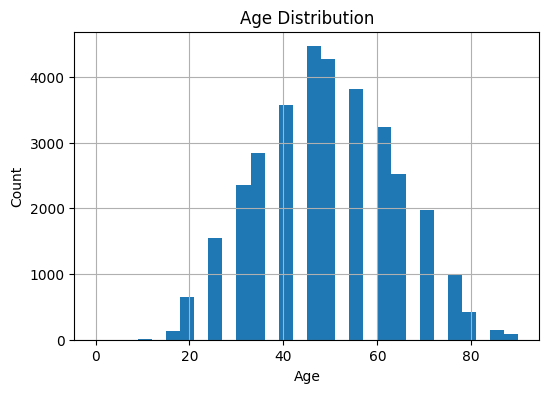

In [15]:
plt.figure(figsize=(6, 4))
df["age_approx"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

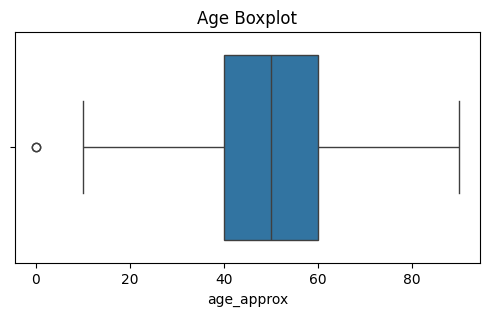

In [16]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df["age_approx"])
plt.title("Age Boxplot")
plt.show()

In [17]:
print(df[df["age_approx"] < 1][["image_name", "patient_id", "age_approx"]].head(20))
print(df[df["age_approx"] > 100][["image_name", "patient_id", "age_approx"]].head(20))

         image_name  patient_id  age_approx
9647   ISIC_2988939  IP_1300691         0.0
22645  ISIC_6872638  IP_1300691         0.0
Empty DataFrame
Columns: [image_name, patient_id, age_approx]
Index: []


In [18]:
df["sex"].value_counts(dropna=False)

sex
male      17080
female    15981
NaN          65
Name: count, dtype: int64

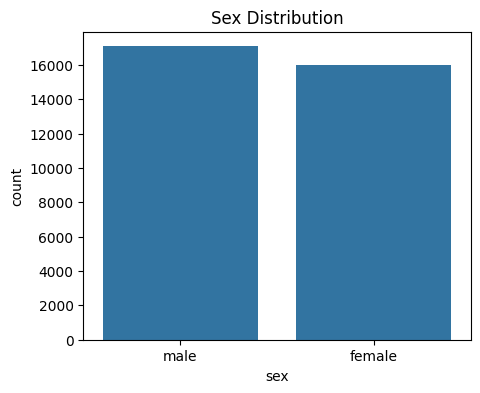

In [19]:
plt.figure(figsize=(5, 4))
sns.countplot(x="sex", data=df)
plt.title("Sex Distribution")
plt.show()

In [20]:
df["anatom_site_general_challenge"].value_counts(dropna=False)

anatom_site_general_challenge
torso              16845
lower extremity     8417
upper extremity     4983
head/neck           1855
NaN                  527
palms/soles          375
oral/genital         124
Name: count, dtype: int64

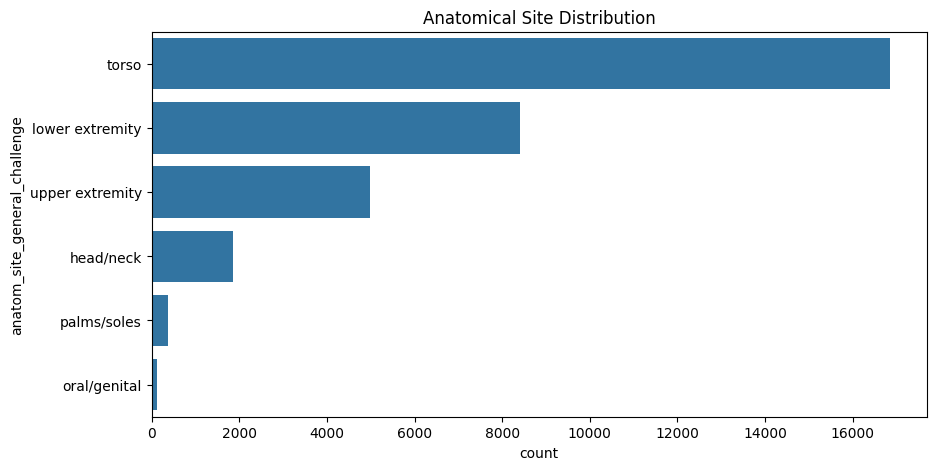

In [21]:
plt.figure(figsize=(10, 5))
sns.countplot(
    y="anatom_site_general_challenge",
    data=df,
    order=df["anatom_site_general_challenge"].value_counts().index
)
plt.title("Anatomical Site Distribution")
plt.show()

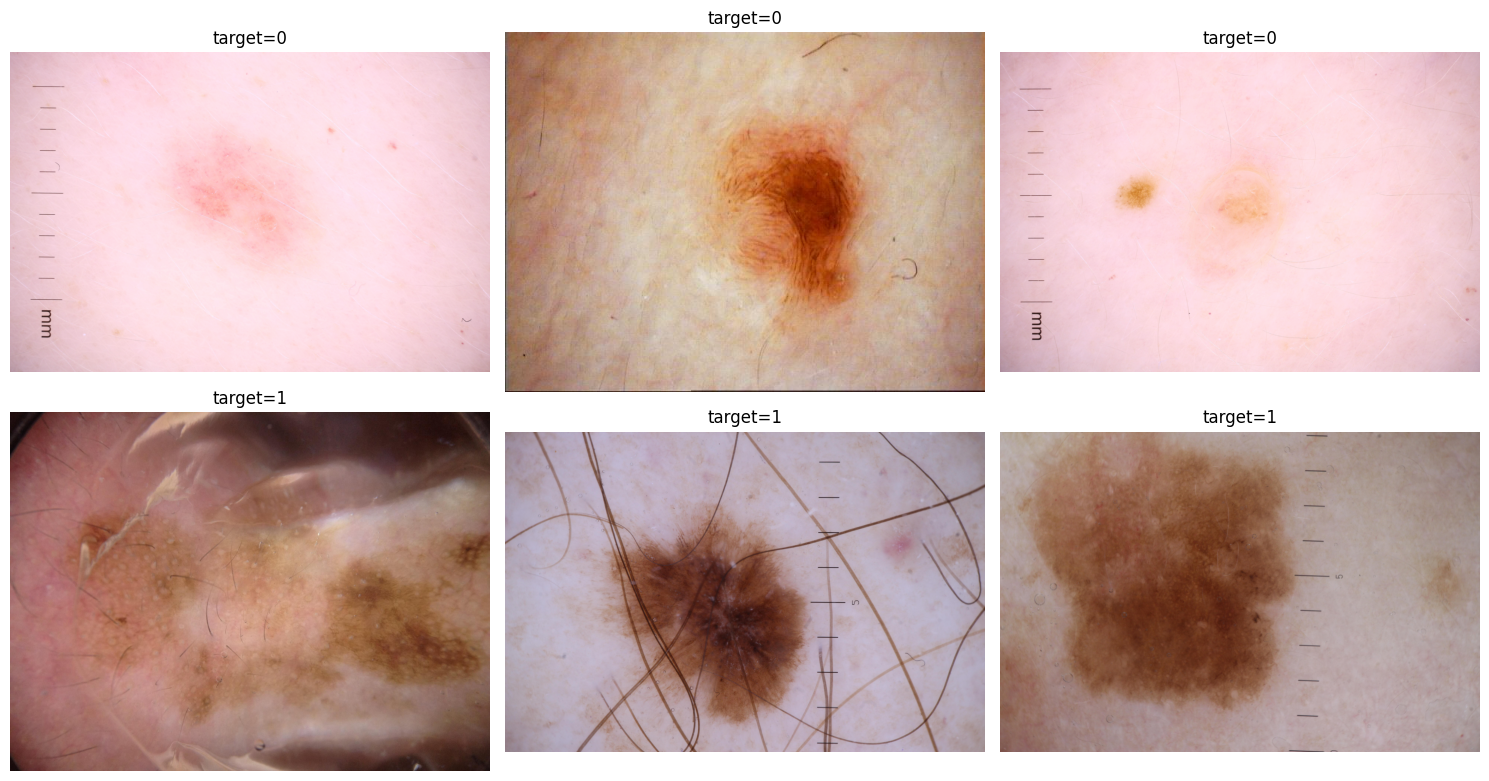

In [ ]:
benign_samples = df[df["target"] == 0].sample(3, random_state=42)
malignant_samples = df[df["target"] == 1].sample(3, random_state=42)

sample_df = pd.concat([benign_samples, malignant_samples])

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    img_path = DATASET_PATH / "jpeg" / "train" / f"{row['image_name']}.jpg"
    img = Image.open(img_path).convert("RGB")

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(f"target={row['target']}")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [23]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(gss.split(df, groups=df["patient_id"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)

print("\nUnique patients:")
print("Train:", train_df["patient_id"].nunique())
print("Val:", val_df["patient_id"].nunique())

overlap = set(train_df["patient_id"]).intersection(set(val_df["patient_id"]))
print("\nOverlapping patients:", len(overlap))

Train shape: (26161, 8)
Val shape: (6965, 8)

Unique patients:
Train: 1644
Val: 412

Overlapping patients: 0


In [24]:
print("Train target distribution:")
print(train_df["target"].value_counts())
print(train_df["target"].value_counts(normalize=True) * 100)

print("\nVal target distribution:")
print(val_df["target"].value_counts())
print(val_df["target"].value_counts(normalize=True) * 100)

Train target distribution:
target
0    25704
1      457
Name: count, dtype: int64
target
0    98.253125
1     1.746875
Name: proportion, dtype: float64

Val target distribution:
target
0    6838
1     127
Name: count, dtype: int64
target
0    98.176597
1     1.823403
Name: proportion, dtype: float64


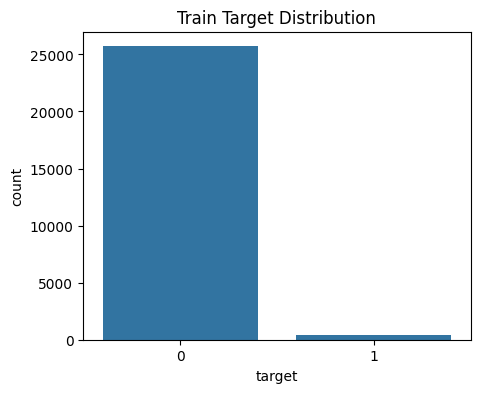

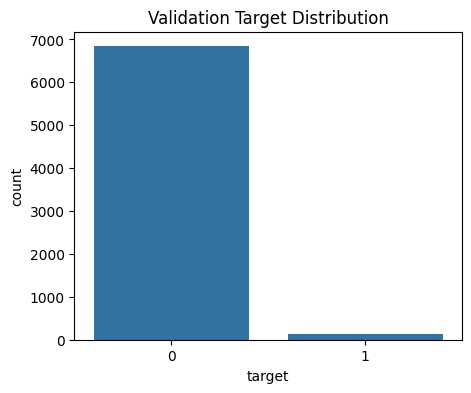

In [25]:
plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=train_df)
plt.title("Train Target Distribution")
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=val_df)
plt.title("Validation Target Distribution")
plt.show()

In [26]:
print("Train missing values:")
print(train_df.isnull().sum().sort_values(ascending=False))

print("\nVal missing values:")
print(val_df.isnull().sum().sort_values(ascending=False))

Train missing values:
anatom_site_general_challenge    301
age_approx                        20
sex                               17
image_name                         0
patient_id                         0
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64

Val missing values:
anatom_site_general_challenge    226
sex                               48
age_approx                        48
image_name                         0
patient_id                         0
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64


In [27]:
print(train_df["sex"].unique())
val_df["sex"].unique()

<StringArray>
['female', 'male', nan]
Length: 3, dtype: str


<StringArray>
['male', 'female', nan]
Length: 3, dtype: str

In [28]:
sex_mode = train_df["sex"].mode()[0]

train_df["sex"] = train_df["sex"].fillna(sex_mode)
val_df["sex"] = val_df["sex"].fillna(sex_mode)

In [29]:
print(train_df["age_approx"].unique())
val_df["age_approx"].unique()

[45. 55. 25. 35. 30. 50. 75. 70. 40. 60. 65. 80. 20. 85. 15. nan 90. 10.]


array([45., 50., 40., 75., 65., 55., nan, 70., 60., 35., 30., 25., 20.,
       85., 80., 90., 10., 15.,  0.])

In [30]:
age_median = train_df["age_approx"].replace(0, np.nan).median()

In [31]:
for df_ in [train_df, val_df]:
    df_["age_approx"] = df_["age_approx"].replace(0, np.nan)
    df_["age_approx"] = df_["age_approx"].fillna(age_median)

In [32]:
print(train_df["anatom_site_general_challenge"].unique())
val_df["anatom_site_general_challenge"].unique()

<StringArray>
[      'head/neck', 'upper extremity', 'lower extremity',           'torso',
               nan,     'palms/soles',    'oral/genital']
Length: 7, dtype: str


<StringArray>
[      'head/neck', 'upper extremity', 'lower extremity',           'torso',
               nan,     'palms/soles',    'oral/genital']
Length: 7, dtype: str

In [33]:
site_mode = train_df["anatom_site_general_challenge"].mode()[0]

train_df["anatom_site_general_challenge"] = train_df["anatom_site_general_challenge"].fillna(site_mode)
val_df["anatom_site_general_challenge"] = val_df["anatom_site_general_challenge"].fillna(site_mode)

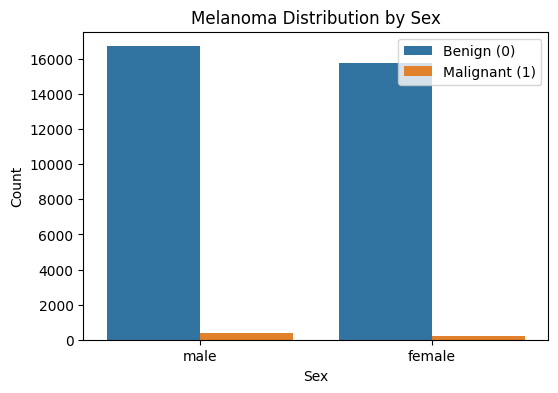

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex", hue="target", data=df)
plt.title("Melanoma Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(["Benign (0)", "Malignant (1)"])
plt.show()

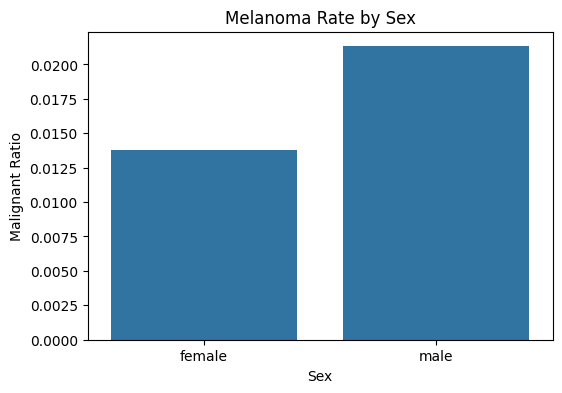

In [35]:
sex_target = df.groupby("sex")["target"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x="sex", y="target", data=sex_target)

plt.title("Melanoma Rate by Sex")
plt.ylabel("Malignant Ratio")
plt.xlabel("Sex")

plt.show()

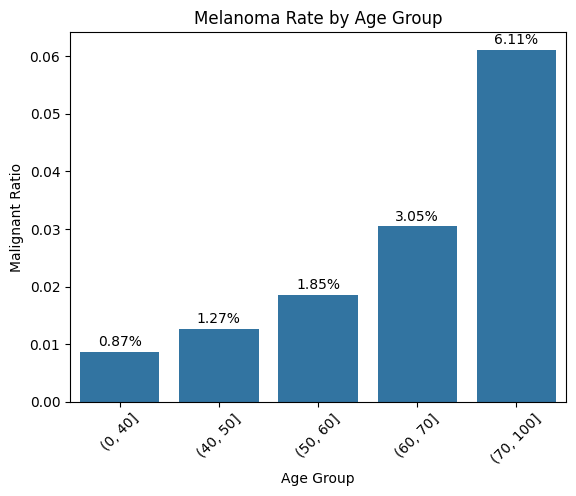

In [36]:
train_df["age_bin"] = pd.cut(
    train_df["age_approx"],
    bins=[0, 40, 50, 60, 70, 100]
)


age_target = train_df.groupby("age_bin")["target"].mean().reset_index()


sns.barplot(x="age_bin", y="target", data=age_target)

plt.title("Melanoma Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Malignant Ratio")

plt.xticks(rotation=45)


for i, row in age_target.iterrows():
    plt.text(i, row["target"] + 0.001, f"{row['target']*100:.2f}%", ha='center')

plt.show()